# RMA Benchmark Analysis
## Lock/Unlock vs Fence vs PSCW vs SendRecv Performance Comparison
### Including Put and Get Operations

In [248]:
import re
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [249]:
def parse_benchmark_file(filename):
    results = []
    
    ansi_escape = re.compile(r'\x1B(?:[@-Z\\-_]|\[[0-?]*[ -/]*[@-~])')
    
    with open(filename, 'r') as f:
        for line in f:
            clean_line = ansi_escape.sub('', line)
            
            match = re.search(
                r'benchmark_(\w+)/(\d+)/manual_time\s+([\d.]+)\s+us.*bytes_per_second=([\d.]+)(Mi|Gi)/s',
                clean_line
            )
            
            if match:
                operation_raw = match.group(1)

                operation = operation_raw.replace('lock_unlock_put', 'LockUnlockPut') \
                                        .replace('lock_unlock_shared_get', 'LockUnlockSharedGet') \
                                        .replace('fence_put', 'FencePut') \
                                        .replace('pscw_put', 'PSCWPut') \
                                        .replace('pscw_get', 'PSCWGet') \
                                        .replace('sendrecv_comparison', 'SendRecv')
                
                msg_size = int(match.group(2))
                time_us = float(match.group(3))
                throughput = float(match.group(4))
                unit = match.group(5)
                
                # Convert to Gi/s
                throughput_gis = throughput / 1024.0 if unit == 'Mi' else throughput
                
                results.append({
                    'Operation': operation,
                    'MessageSize': msg_size,
                    'Time_us': time_us,
                    'Throughput_Gis': throughput_gis
                })
    
    return pd.DataFrame(results)

df = parse_benchmark_file('results.txt')

print(f"Loaded {len(df)} benchmarks")

Loaded 42 benchmarks


In [250]:
df

,Operation,MessageSize,Time_us,Throughput_Gis
0,LockUnlockPut,1,2.390,0.003111
1,LockUnlockPut,8,2.550,0.023343
2,LockUnlockPut,64,2.440,0.195625
3,LockUnlockPut,512,2.570,1.482370
4,LockUnlockPut,4096,4.460,6.844640
5,LockUnlockPut,32768,17.100,14.243900
6,LockUnlockPut,262144,125.000,15.580400
7,LockUnlockSharedGet,1,2.750,0.002707
8,LockUnlockSharedGet,8,3.220,0.018521
9,LockUnlockSharedGet,64,2.850,0.167079


['LockUnlockPut' 'LockUnlockSharedGet' 'FencePut' 'SendRecv' 'PSCWPut'
 'PSCWGet']


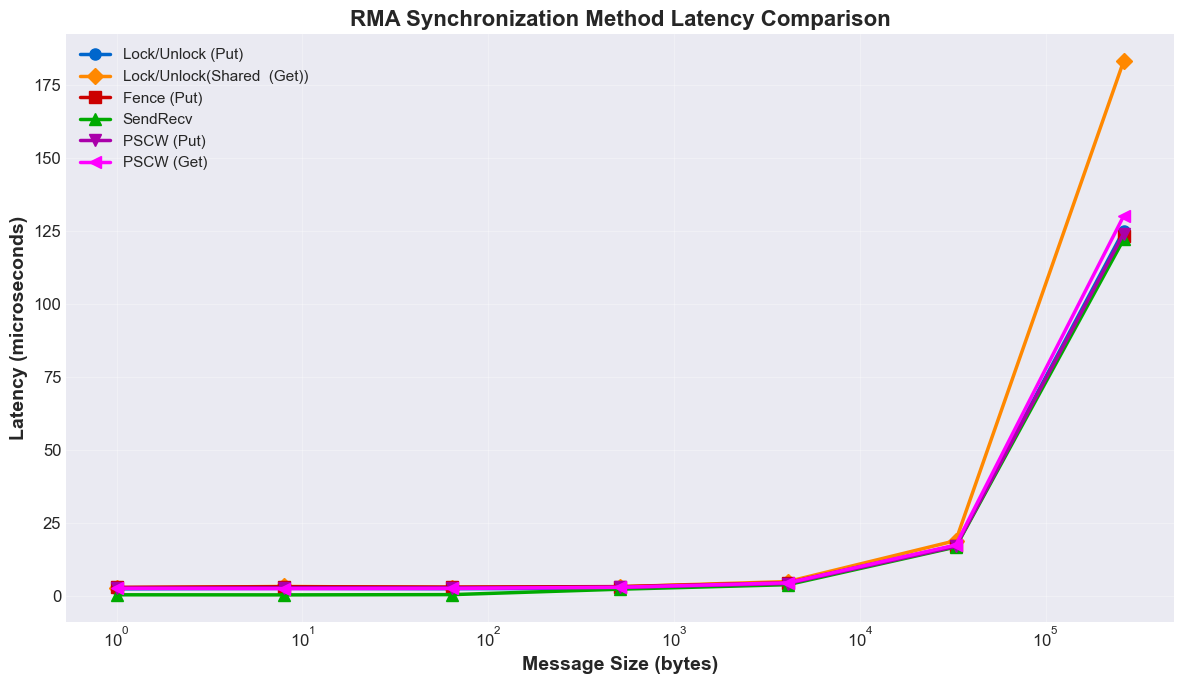

Graph saved as: latency_comparison.png


In [251]:
fig, ax = plt.subplots(figsize=(12, 7))

operations = df['Operation'].unique()
print(operations)
colors = {'LockUnlockPut': '#0066CC', 'FencePut': '#CC0000', 
          'SendRecv': '#00AA00', 'LockUnlockSharedGet': '#FF8800', 
          'PSCWPut': '#AA00AA', 'PSCWGet': '#FF00FF'}
markers = {'LockUnlockPut': 'o', 'FencePut': 's', 'SendRecv': '^', 
           'LockUnlockSharedGet': 'D', 'PSCWPut': 'v', 'PSCWGet': '<'}

for op in operations:
    data_subset = df[df['Operation'] == op]
    ax.plot(data_subset['MessageSize'], data_subset['Time_us'], 
            marker=markers.get(op, 'o'), linewidth=2.5, markersize=8,
            label=op.replace('LockUnlock', 'Lock/Unlock').replace('Put', ' (Put)').replace('SharedGet', '(Shared Get)').replace('Get', ' (Get)'),
            color=colors.get(op, '#000000'))

ax.set_xscale('log')
ax.set_xlabel('Message Size (bytes)', fontsize=14, fontweight='bold')
ax.set_ylabel('Latency (microseconds)', fontsize=14, fontweight='bold')
ax.set_title('RMA Synchronization Method Latency Comparison', fontsize=16, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('latency_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Graph saved as: latency_comparison.png")

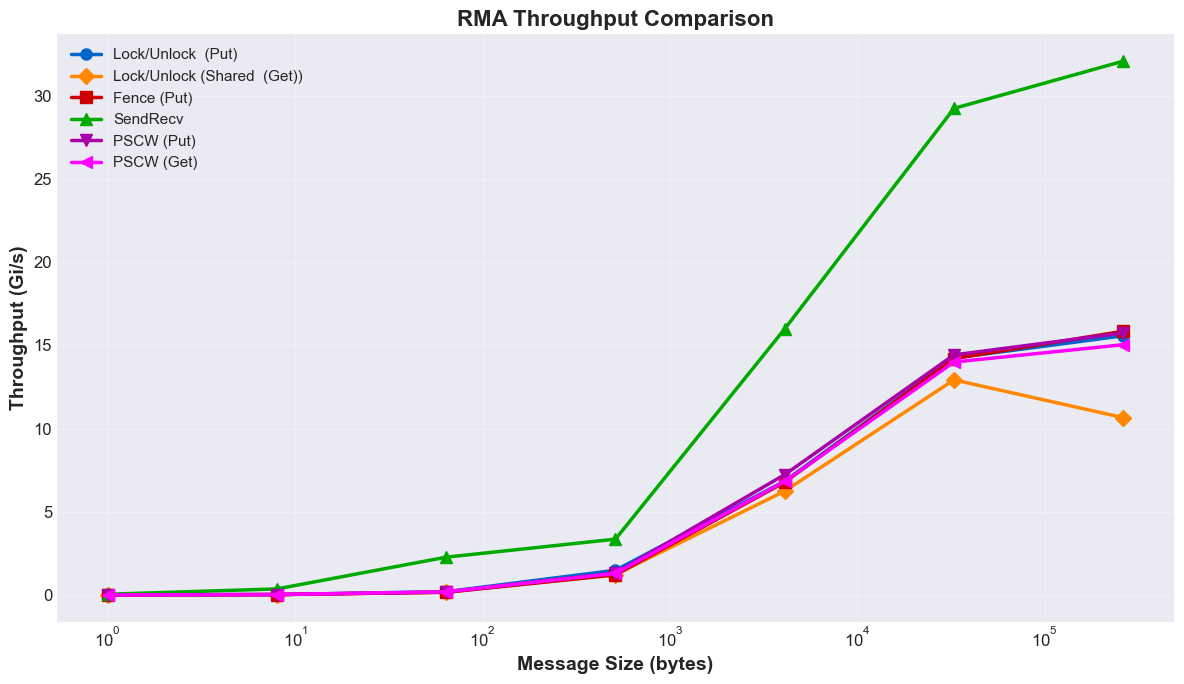

Graph saved as: throughput_comparison.png


In [252]:
fig, ax = plt.subplots(figsize=(12, 7))

for op in operations:
    data_subset = df[df['Operation'] == op]
    ax.plot(data_subset['MessageSize'], data_subset['Throughput_Gis'], 
            marker=markers.get(op, 'o'), linewidth=2.5, markersize=8,
            label=op.replace('LockUnlock', 'Lock/Unlock ').replace('Put', ' (Put)').replace('SharedGet', '(Shared Get)').replace('Get', ' (Get)'),
            color=colors.get(op, '#000000'))

ax.set_xscale('log')
ax.set_xlabel('Message Size (bytes)', fontsize=14, fontweight='bold')
ax.set_ylabel('Throughput (Gi/s)', fontsize=14, fontweight='bold')
ax.set_title('RMA Throughput Comparison', fontsize=16, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('throughput_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Graph saved as: throughput_comparison.png")

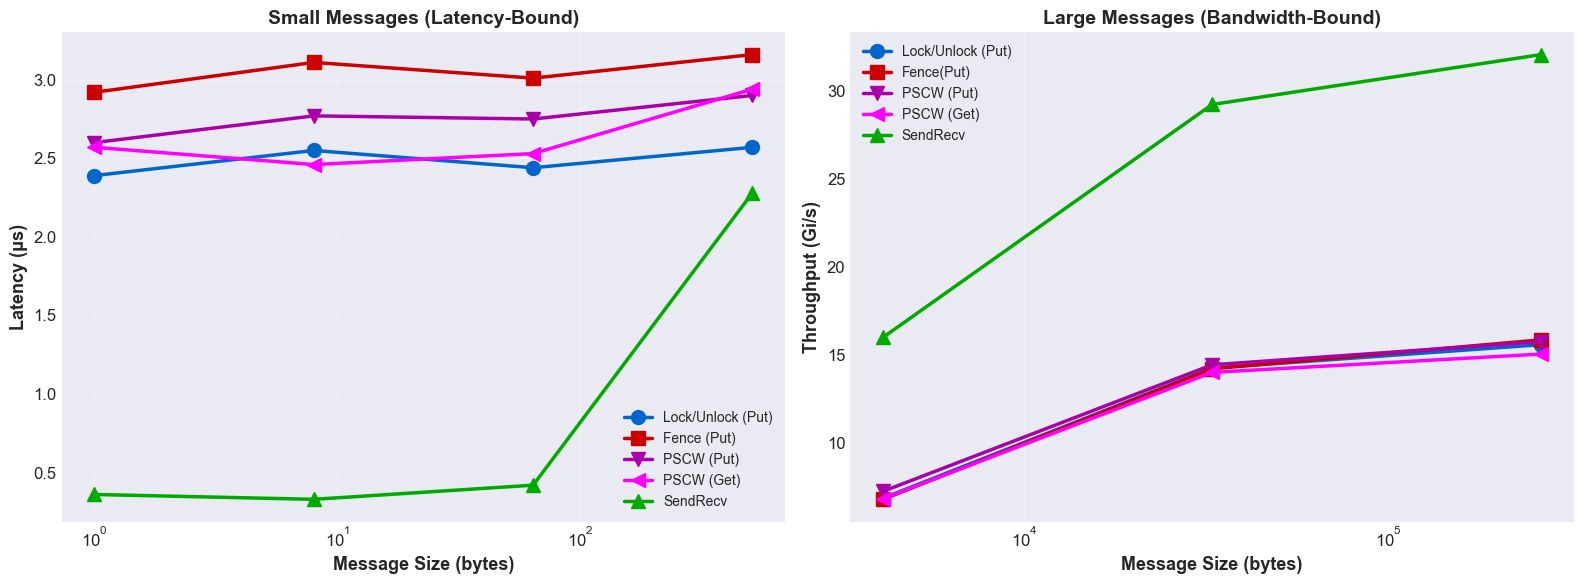

Graph saved as: small_vs_large_comparison.png


In [253]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

small_sizes = [1, 8, 64, 512]
for op in ['LockUnlockPut', 'FencePut', 'PSCWPut', 'PSCWGet', 'SendRecv']:
    if op in df['Operation'].values:
        data_subset = df[(df['Operation'] == op) & (df['MessageSize'].isin(small_sizes))]
        ax1.plot(data_subset['MessageSize'], data_subset['Time_us'], 
                marker=markers.get(op, 'o'), linewidth=2.5, markersize=10,
                label=op.replace('LockUnlock', 'Lock/Unlock').replace('Put', ' (Put)').replace('Get', ' (Get)'),
                color=colors.get(op, '#000000'))

ax1.set_xscale('log')
ax1.set_xlabel('Message Size (bytes)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Latency (μs)', fontsize=13, fontweight='bold')
ax1.set_title('Small Messages (Latency-Bound)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

large_sizes = [4096, 32768, 262144]
for op in ['LockUnlockPut', 'FencePut', 'PSCWPut', 'PSCWGet', 'SendRecv']:
    if op in df['Operation'].values:
        data_subset = df[(df['Operation'] == op) & (df['MessageSize'].isin(large_sizes))]
        ax2.plot(data_subset['MessageSize'], data_subset['Throughput_Gis'], 
                marker=markers.get(op, 'o'), linewidth=2.5, markersize=10,
                label=op.replace('LockUnlock', 'Lock/Unlock ').replace('Put', '(Put)').replace('PSCW', 'PSCW ').replace('Get', '(Get)'),
                color=colors.get(op, '#000000'))

ax2.set_xscale('log')
ax2.set_xlabel('Message Size (bytes)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Throughput (Gi/s)', fontsize=13, fontweight='bold')
ax2.set_title('Large Messages (Bandwidth-Bound)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('small_vs_large_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Graph saved as: small_vs_large_comparison.png")

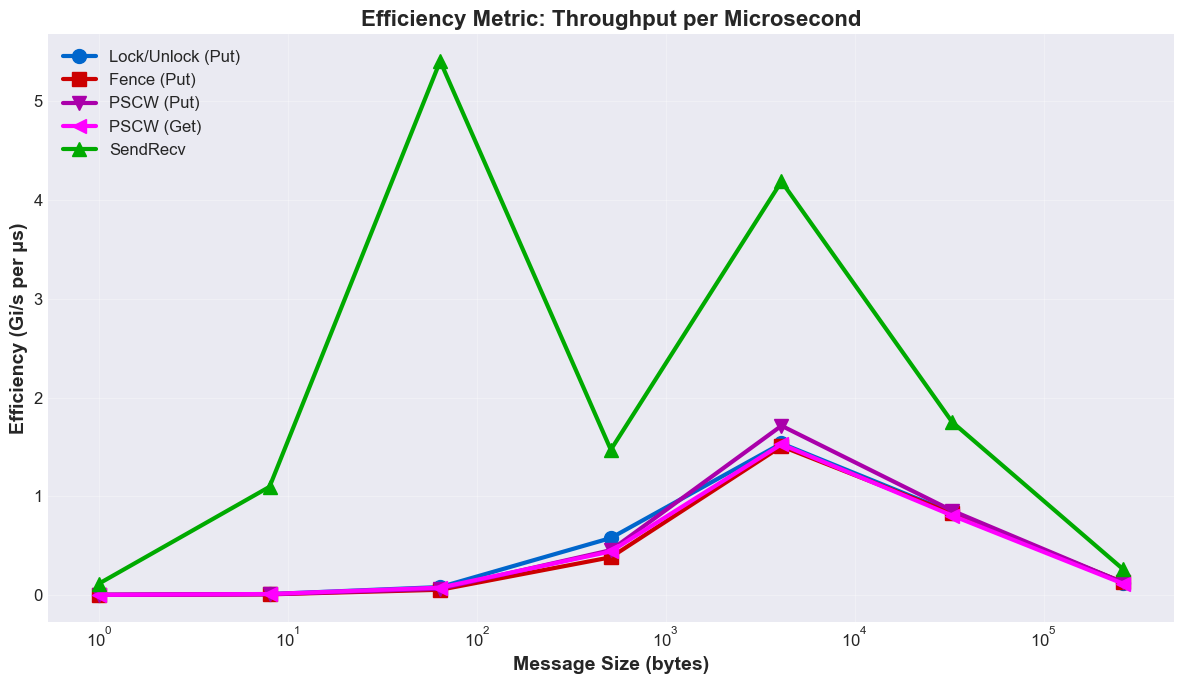

Graph saved as: efficiency_metric.png


In [254]:
fig, ax = plt.subplots(figsize=(12, 7))

for op in rma_ops:
    if op in df['Operation'].values:
        data_subset = df[df['Operation'] == op].copy()
        data_subset['Efficiency'] = data_subset['Throughput_Gis'] / data_subset['Time_us']

        ax.plot(data_subset['MessageSize'], data_subset['Efficiency'],
                marker=markers.get(op, 'o'), linewidth=3, markersize=10,
                label=op.replace('LockUnlock', 'Lock/Unlock').replace('Put', ' (Put)').replace('Get', ' (Get)'),
                color=colors.get(op, '#000000'))

ax.set_xscale('log')
ax.set_xlabel('Message Size (bytes)', fontsize=14, fontweight='bold')
ax.set_ylabel('Efficiency (Gi/s per μs)', fontsize=14, fontweight='bold')
ax.set_title('Efficiency Metric: Throughput per Microsecond', fontsize=16, fontweight='bold')
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('efficiency_metric.png', dpi=300, bbox_inches='tight')
plt.show()

print("Graph saved as: efficiency_metric.png")

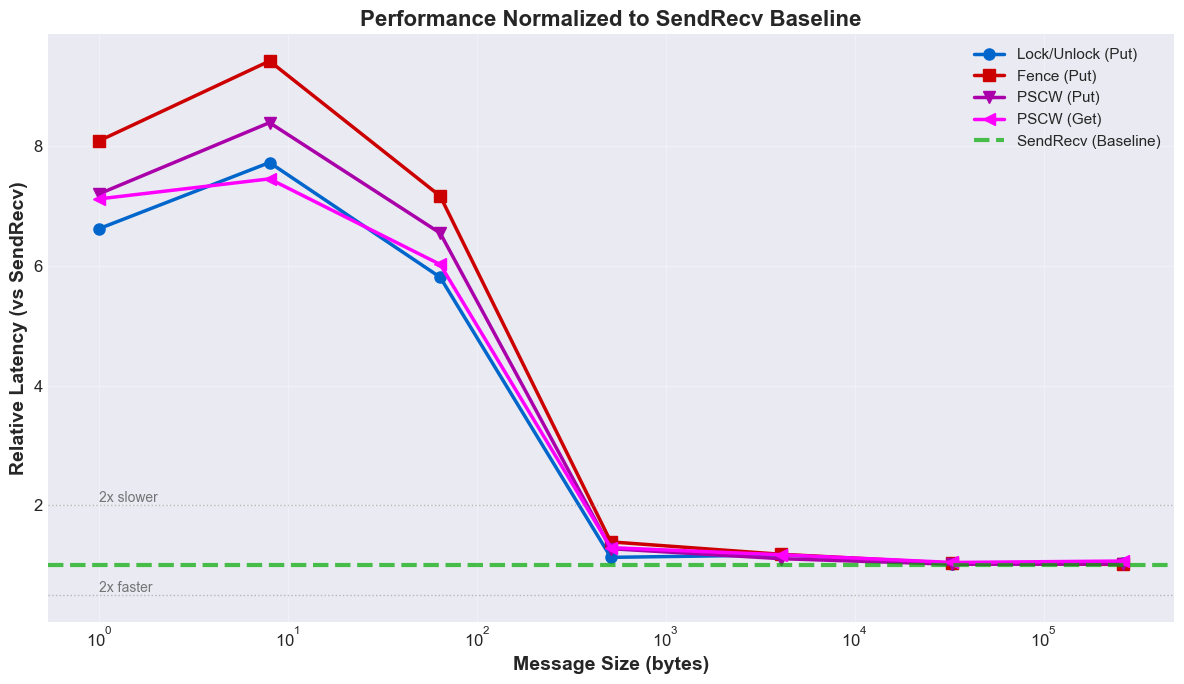

Graph saved as: normalized_performance.png


In [255]:
sendrecv_data = df[df['Operation'] == 'SendRecv'][['MessageSize', 'Time_us']].rename(columns={'Time_us': 'SendRecv_Time'})
normalized_df = df.merge(sendrecv_data, on='MessageSize')
normalized_df['Relative_Latency'] = normalized_df['Time_us'] / normalized_df['SendRecv_Time']

fig, ax = plt.subplots(figsize=(12, 7))

for op in rma_ops:
    if op != 'SendRecv':
        data_subset = normalized_df[normalized_df['Operation'] == op]
        ax.plot(data_subset['MessageSize'], data_subset['Relative_Latency'], 
                marker=markers.get(op, 'o'), linewidth=2.5, markersize=8,
                label=op.replace('LockUnlock', 'Lock/Unlock').replace('Put', ' (Put)').replace('Get', ' (Get)'),
                color=colors.get(op, '#000000'))

ax.axhline(y=1.0, color='#00AA00', linestyle='--', linewidth=3, label='SendRecv (Baseline)', alpha=0.7)
ax.set_xscale('log')
ax.set_xlabel('Message Size (bytes)', fontsize=14, fontweight='bold')
ax.set_ylabel('Relative Latency (vs SendRecv)', fontsize=14, fontweight='bold')
ax.set_title('Performance Normalized to SendRecv Baseline', fontsize=16, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)

ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.axhline(y=2.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.text(1, 0.5, '2x faster', fontsize=10, alpha=0.6, va='bottom')
ax.text(1, 2.0, '2x slower', fontsize=10, alpha=0.6, va='bottom')

plt.tight_layout()
plt.savefig('normalized_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("Graph saved as: normalized_performance.png")